# 📊 Notebook 1 — EDA & Data Preprocessing
**Mental Health Text Sentiment Classifier**

---

## Dataset files

| Path | File | Rows | Cols | Notes |
|---|---|---|---|---|
| `data/raw/primary/` | `CombinedData.csv` | 53,043 | 3 | col: `statement`; 7 labels; mojibake; mixed EN/ID |
| `data/raw/secondary/` | `mental_heath_unbanlanced.csv` | 49,612 | 3 | col: `text`; 4 labels; clean |
| `data/raw/secondary/` | `mental_heath_feature_engineered.csv` | 49,612 | 21 | same texts + 18 NLP features |
| `data/raw/secondary/` | `mental_health_combined_test.csv` | 992 | 2 | **pre-built balanced test set — never touch** |

## Label mapping (7 classes → 3 risk tiers)
| Original Label | Source | Risk Tier | Numeric |
|---|---|---|---|
| Normal | Both | Low Risk | 0 |
| Stress | Primary only | Moderate Risk | 1 |
| Anxiety | Both | Moderate Risk | 1 |
| Personality disorder | Primary only | Moderate Risk | 1 |
| Depression | Both | High Risk | 2 |
| Suicidal | Both | High Risk | 2 |
| Bipolar | Primary only | High Risk | 2 |

## Known data issues (handled in this notebook)
- Primary column is `statement`, not `text` → rename on load
- Primary has `Unnamed: 0` index column → drop on load  
- Primary has mojibake encoding artifacts (`‚Ñ¢`, `¬±`, `Ô∏è`, etc.) → stripped in cleaner
- Primary has mixed English / Indonesian-Malay text → noted; non-ASCII stripped
- 496 rows overlap between secondary training data and test set → remove (leakage)
- Must also check primary vs test set for leakage
- ~667 duplicates in secondary → drop
- Merged dataset may have cross-source duplicates → dedup on combined

## 0. Imports & Setup

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import json
import warnings
from pathlib import Path
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from transformers import DistilBertTokenizer

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# ── Colour scheme ────────────────────────────────────────────────────────────
RISK_PALETTE   = ['#2ecc71', '#f39c12', '#e74c3c']      # Low / Moderate / High
CLASS7_PALETTE = ['#2ecc71', '#f1c40f', '#e67e22',       # Normal, Stress, Anxiety
                  '#8e44ad', '#e74c3c', '#c0392b', '#2c3e50']  # PD, Bipolar, Dep, Suicidal
BLUE           = '#2E75B6'

# ── Label maps ───────────────────────────────────────────────────────────────
LABEL_MAP = {
    'Normal':               0,
    'Stress':               1,
    'Anxiety':              1,
    'Personality disorder': 1,
    'Depression':           2,
    'Suicidal':             2,
    'Bipolar':              2,
}
RISK_NAMES = {0: 'Low Risk', 1: 'Moderate Risk', 2: 'High Risk'}

# ── Paths ────────────────────────────────────────────────────────────────────
RAW_PRI   = Path('data/raw/primary/')
RAW_SEC   = Path('data/raw/secondary/')
PROCESSED = Path('data/processed/')
RESULTS   = Path('results/')
for p in [PROCESSED, RESULTS]:
    p.mkdir(parents=True, exist_ok=True)

print('Setup complete.')

Setup complete.


---
## 1. Load All Files

In [21]:
# ── Primary dataset ──────────────────────────────────────────────────────────
df_primary = pd.read_csv(RAW_PRI / 'CombinedData.csv')
print(f'Primary raw shape   : {df_primary.shape}')
print(f'Primary columns     : {df_primary.columns.tolist()}')
print(f'Primary labels      : {sorted(df_primary["status"].unique())}')
print(f'Primary label dist  :')
print(df_primary['status'].value_counts().to_string())
df_primary.head(3)

Primary raw shape   : (53043, 3)
Primary columns     : ['Unnamed: 0', 'statement', 'status']
Primary labels      : ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']
Primary label dist  :
status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety


In [22]:
# ── Secondary datasets ───────────────────────────────────────────────────────
df_secondary = pd.read_csv(RAW_SEC / 'mental_heath_unbanlanced.csv')
df_feat      = pd.read_csv(RAW_SEC / 'mental_heath_feature_engineered.csv')
df_test      = pd.read_csv(RAW_SEC / 'mental_health_combined_test.csv')

print(f'Secondary raw shape : {df_secondary.shape}')
print(f'Feature eng. shape  : {df_feat.shape}')
print(f'Test set shape      : {df_test.shape}  <- balanced, HELD OUT')

Secondary raw shape : (49612, 3)
Feature eng. shape  : (49612, 21)
Test set shape      : (992, 2)  <- balanced, HELD OUT


---
## 2. Standardise & Merge

In [23]:
# ── Standardise primary ──────────────────────────────────────────────────────
# Rename 'statement' -> 'text', drop the unnamed index column
df_pri = df_primary[['statement', 'status']].copy()
df_pri.rename(columns={'statement': 'text'}, inplace=True)
df_pri['source'] = 'primary'

# ── Standardise secondary ────────────────────────────────────────────────────
df_sec = df_secondary[['text', 'status']].copy()
df_sec['source'] = 'secondary'

# ── Standardise test set ─────────────────────────────────────────────────────
df_test_clean = df_test[['text', 'status']].dropna().drop_duplicates(subset=['text']).reset_index(drop=True)
df_test_clean['source'] = 'test'

print(f'Primary standardised  : {len(df_pri):,} rows')
print(f'Secondary standardised: {len(df_sec):,} rows')
print(f'Test set              : {len(df_test_clean):,} rows')

Primary standardised  : 53,043 rows
Secondary standardised: 49,612 rows
Test set              : 992 rows


In [24]:
# ── Merge primary + secondary ─────────────────────────────────────────────────
df_combined = pd.concat([df_pri, df_sec], ignore_index=True)
print(f'Combined (before cleaning): {len(df_combined):,} rows')

# ── Data quality checks ───────────────────────────────────────────────────────
n_null  = df_combined[['text','status']].isnull().any(axis=1).sum()
n_empty = (df_combined['text'].str.strip() == '').sum()
n_dup   = df_combined.duplicated(subset=['text']).sum()

# Test set overlap (check BOTH sources)
test_texts    = set(df_test_clean['text'].values)
n_leakage     = df_combined['text'].isin(test_texts).sum()

print(f'  Null rows           : {n_null:,}')
print(f'  Empty text rows     : {n_empty:,}')
print(f'  Duplicate texts     : {n_dup:,}')
print(f'  Test-set leakage    : {n_leakage:,} rows <- removing')

Combined (before cleaning): 102,655 rows
  Null rows           : 362
  Empty text rows     : 0
  Duplicate texts     : 40,907
  Test-set leakage    : 496 rows <- removing


In [25]:
# ── Clean ─────────────────────────────────────────────────────────────────────
df_clean = df_combined.copy()
df_clean = df_clean.dropna(subset=['text', 'status'])
df_clean = df_clean[df_clean['text'].str.strip() != '']
df_clean = df_clean[~df_clean['text'].isin(test_texts)]     # remove leakage
df_clean = df_clean.drop_duplicates(subset=['text'])        # keep first occurrence
df_clean = df_clean.reset_index(drop=True)

print(f'Rows before cleaning : {len(df_combined):,}')
print(f'Rows after  cleaning : {len(df_clean):,}')
print(f'Removed              : {len(df_combined) - len(df_clean):,}')
print(f'\nSource breakdown after cleaning:')
print(df_clean['source'].value_counts().to_string())

Rows before cleaning : 102,655
Rows after  cleaning : 61,251
Removed              : 41,404

Source breakdown after cleaning:
source
primary      51073
secondary    10178


In [46]:
primary   = pd.read_csv('data/raw/primary/CombinedData.csv')
secondary = pd.read_csv('data/raw/secondary/mental_heath_unbanlanced.csv')

# Normalise for comparison the same way the notebook does
primary_texts   = set(primary['statement'].str.strip().str.lower())
secondary_texts = secondary['text'].str.strip().str.lower()

overlap = secondary_texts.isin(primary_texts).sum()
print(f"Secondary texts that exist in primary : {overlap:,} / {len(secondary):,} ({overlap/len(secondary)*100:.1f}%)")

Secondary texts that exist in primary : 39,469 / 49,612 (79.6%)


In [48]:
# Note on dataset overlap
print("NOTE: 79.6% of secondary texts exist verbatim in primary.")
print("The two sources share a common upstream Kaggle corpus.")
print("Dedup is intentional — not data loss.")
print(f"Effective unique training texts: ~{len(df_clean):,}")

NOTE: 79.6% of secondary texts exist verbatim in primary.
The two sources share a common upstream Kaggle corpus.
Dedup is intentional — not data loss.
Effective unique training texts: ~61,251


---
## 3. EDA — Raw Label Distribution (Both Sources)

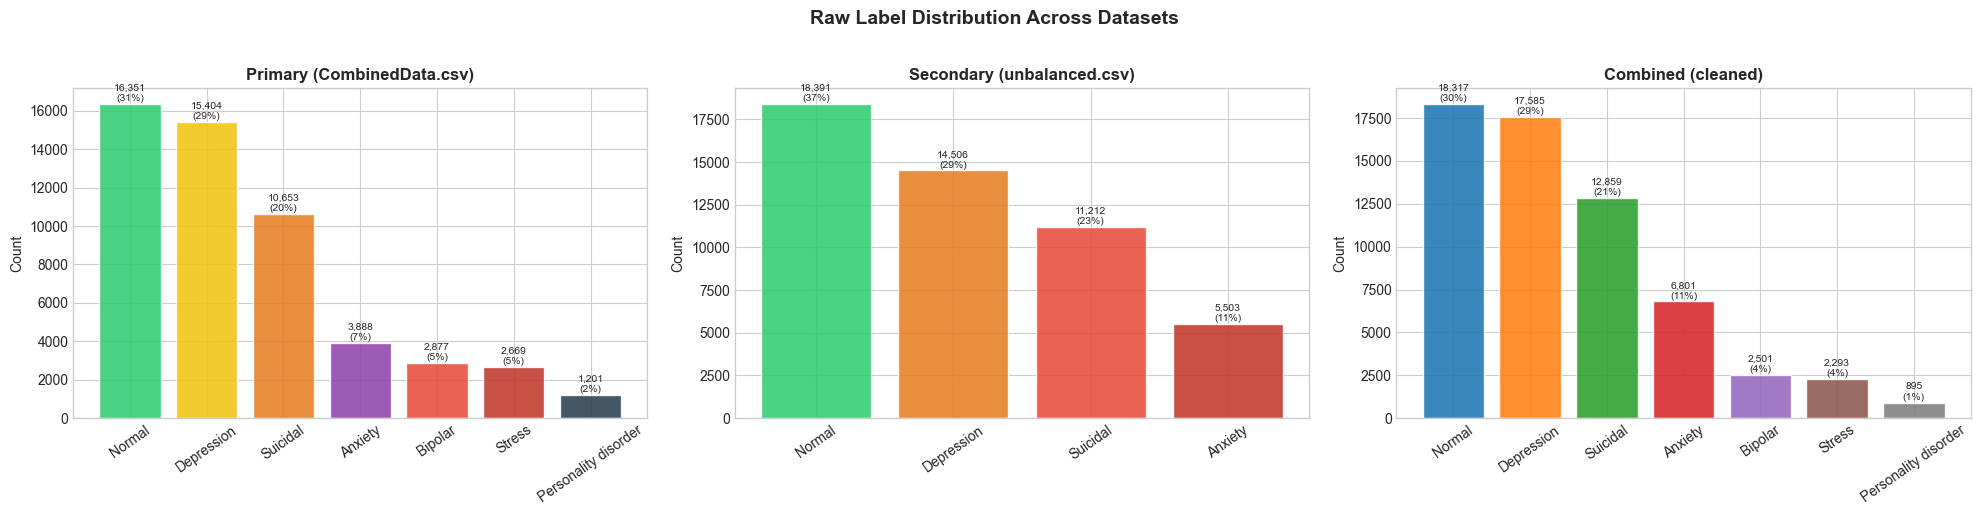

Saved: results/eda_01_raw_labels.png


In [49]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

datasets = [
    ('Primary (CombinedData.csv)', df_pri, CLASS7_PALETTE),
    ('Secondary (unbalanced.csv)', df_sec, ['#2ecc71','#e67e22','#e74c3c','#c0392b']),
    ('Combined (cleaned)', df_clean, None),
]

for ax, (title, df_src, palette) in zip(axes, datasets):
    counts = df_src['status'].value_counts()
    colors = palette if palette else plt.cm.tab10(np.linspace(0, 0.7, len(counts)))
    bars = ax.bar(counts.index, counts.values, color=colors, alpha=0.88, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=35)
    for bar, count in zip(bars, counts.values):
        pct = count / len(df_src) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{count:,}\n({pct:.0f}%)', ha='center', va='bottom', fontsize=7.5)

plt.suptitle('Raw Label Distribution Across Datasets', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS / 'eda_01_raw_labels.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/eda_01_raw_labels.png')

In [27]:
# ── Labels unique to primary (Bipolar, Stress, Personality disorder) ──────────
primary_only_labels = set(df_pri['status'].unique()) - set(df_sec['status'].unique())
both_labels         = set(df_pri['status'].unique()) & set(df_sec['status'].unique())
print(f'Labels in BOTH sources : {sorted(both_labels)}')
print(f'Labels in PRIMARY only : {sorted(primary_only_labels)}')
print()
print('Primary-only label counts:')
print(df_pri[df_pri['status'].isin(primary_only_labels)]['status'].value_counts().to_string())

Labels in BOTH sources : ['Anxiety', 'Depression', 'Normal', 'Suicidal']
Labels in PRIMARY only : ['Bipolar', 'Personality disorder', 'Stress']

Primary-only label counts:
status
Bipolar                 2877
Stress                  2669
Personality disorder    1201


---
## 4. Label Consolidation: 7 Classes → 3 Risk Tiers

In [28]:
df_clean['risk_label'] = df_clean['status'].map(LABEL_MAP)

# Sanity check — no unmapped labels
unmapped = df_clean[df_clean['risk_label'].isna()]['status'].unique()
if len(unmapped):
    print(f'WARNING - unmapped labels: {unmapped}')
else:
    print('All labels mapped successfully.')

df_clean['risk_label'] = df_clean['risk_label'].astype(int)
df_clean['risk_name']  = df_clean['risk_label'].map(RISK_NAMES)

# Apply same map to test set
df_test_clean['risk_label'] = df_test_clean['status'].map(LABEL_MAP).astype(int)
df_test_clean['risk_name']  = df_test_clean['risk_label'].map(RISK_NAMES)

print('\nCombined training — risk tier distribution:')
rc = df_clean['risk_name'].value_counts()
for name in ['Low Risk', 'Moderate Risk', 'High Risk']:
    n   = rc.get(name, 0)
    pct = n / len(df_clean) * 100
    print(f'  {name:<18}: {n:>7,}  ({pct:.1f}%)')

All labels mapped successfully.

Combined training — risk tier distribution:
  Low Risk          :  18,317  (29.9%)
  Moderate Risk     :   9,989  (16.3%)
  High Risk         :  32,945  (53.8%)


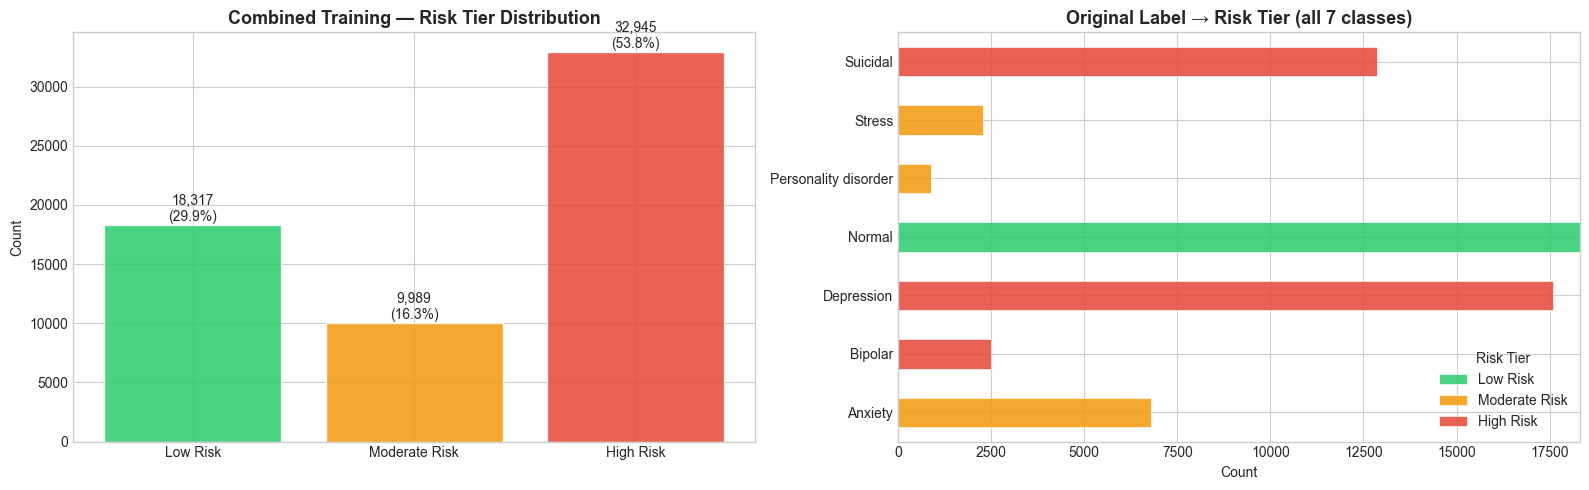

Saved: results/eda_02_risk_tiers.png


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ordered = ['Low Risk', 'Moderate Risk', 'High Risk']

# ── Bar: risk tier distribution ───────────────────────────────────────────────
risk_counts = df_clean['risk_name'].value_counts().reindex(ordered)
bars = axes[0].bar(risk_counts.index, risk_counts.values,
                   color=RISK_PALETTE, alpha=0.88, edgecolor='white')
axes[0].set_title('Combined Training — Risk Tier Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, risk_counts.values):
    pct = val / len(df_clean) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

# ── Stacked bar: which original labels feed each tier, split by source ────────
mapping_df = df_clean.groupby(['status', 'risk_name', 'source']).size().reset_index(name='count')
pivot = df_clean.groupby(['status', 'risk_name']).size().reset_index(name='count')
pivot2 = pivot.pivot(index='status', columns='risk_name', values='count').fillna(0)
pivot2 = pivot2.reindex(columns=ordered, fill_value=0)
pivot2.plot(kind='barh', stacked=True, ax=axes[1],
            color=RISK_PALETTE, edgecolor='white', linewidth=0.5, alpha=0.88)
axes[1].set_title('Original Label → Risk Tier (all 7 classes)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('')
axes[1].legend(title='Risk Tier', loc='lower right')

plt.tight_layout()
plt.savefig(RESULTS / 'eda_02_risk_tiers.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/eda_02_risk_tiers.png')

Source contribution per risk tier:
risk_name  Low Risk  Moderate Risk  High Risk
source                                       
primary       16039           6805      28229
secondary      2278           3184       4716


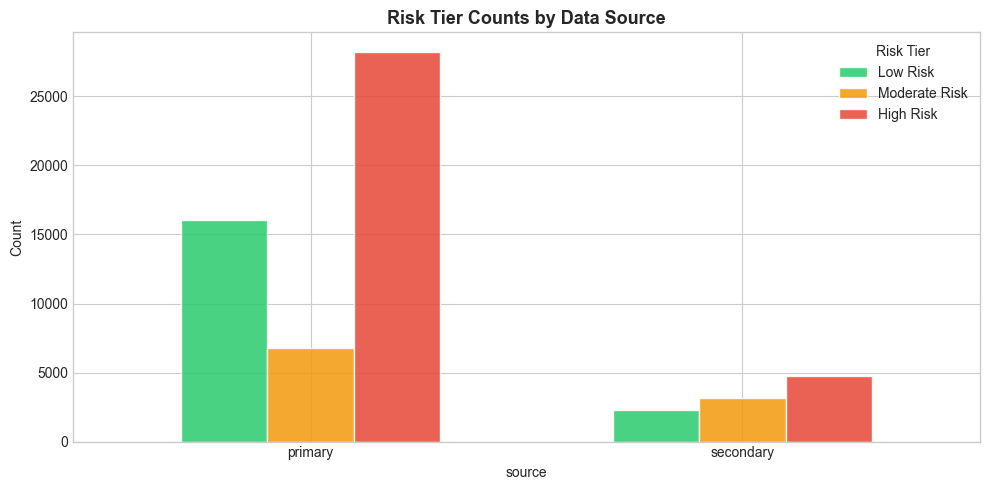

Saved: results/eda_03_source_contribution.png


In [30]:
# ── Source contribution per risk tier ─────────────────────────────────────────
source_tier = df_clean.groupby(['source', 'risk_name']).size().unstack(fill_value=0)
source_tier = source_tier.reindex(columns=ordered, fill_value=0)
print('Source contribution per risk tier:')
print(source_tier.to_string())

ax = source_tier.plot(kind='bar', figsize=(10, 5),
                      color=RISK_PALETTE, alpha=0.88, edgecolor='white', width=0.6)
plt.title('Risk Tier Counts by Data Source', fontsize=13, fontweight='bold')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Risk Tier')
plt.tight_layout()
plt.savefig(RESULTS / 'eda_03_source_contribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/eda_03_source_contribution.png')

---
## 5. Pre-Computed Feature Analysis (feature_engineered.csv)

In [31]:
# Align feature file to cleaned secondary-source rows only
secondary_texts   = set(df_clean[df_clean['source'] == 'secondary']['text'].values)
df_feat_aligned   = df_feat[df_feat['text'].isin(secondary_texts)].copy()
df_feat_aligned   = df_feat_aligned.drop_duplicates(subset=['text'])
df_feat_aligned['risk_label'] = df_feat_aligned['status'].map(LABEL_MAP)
df_feat_valid     = df_feat_aligned.dropna(subset=['text_length']).reset_index(drop=True)
df_feat_valid['risk_label'] = df_feat_valid['risk_label'].astype(int)

print(f'Feature-engineered rows (valid): {len(df_feat_valid):,}')

Feature-engineered rows (valid): 1,075


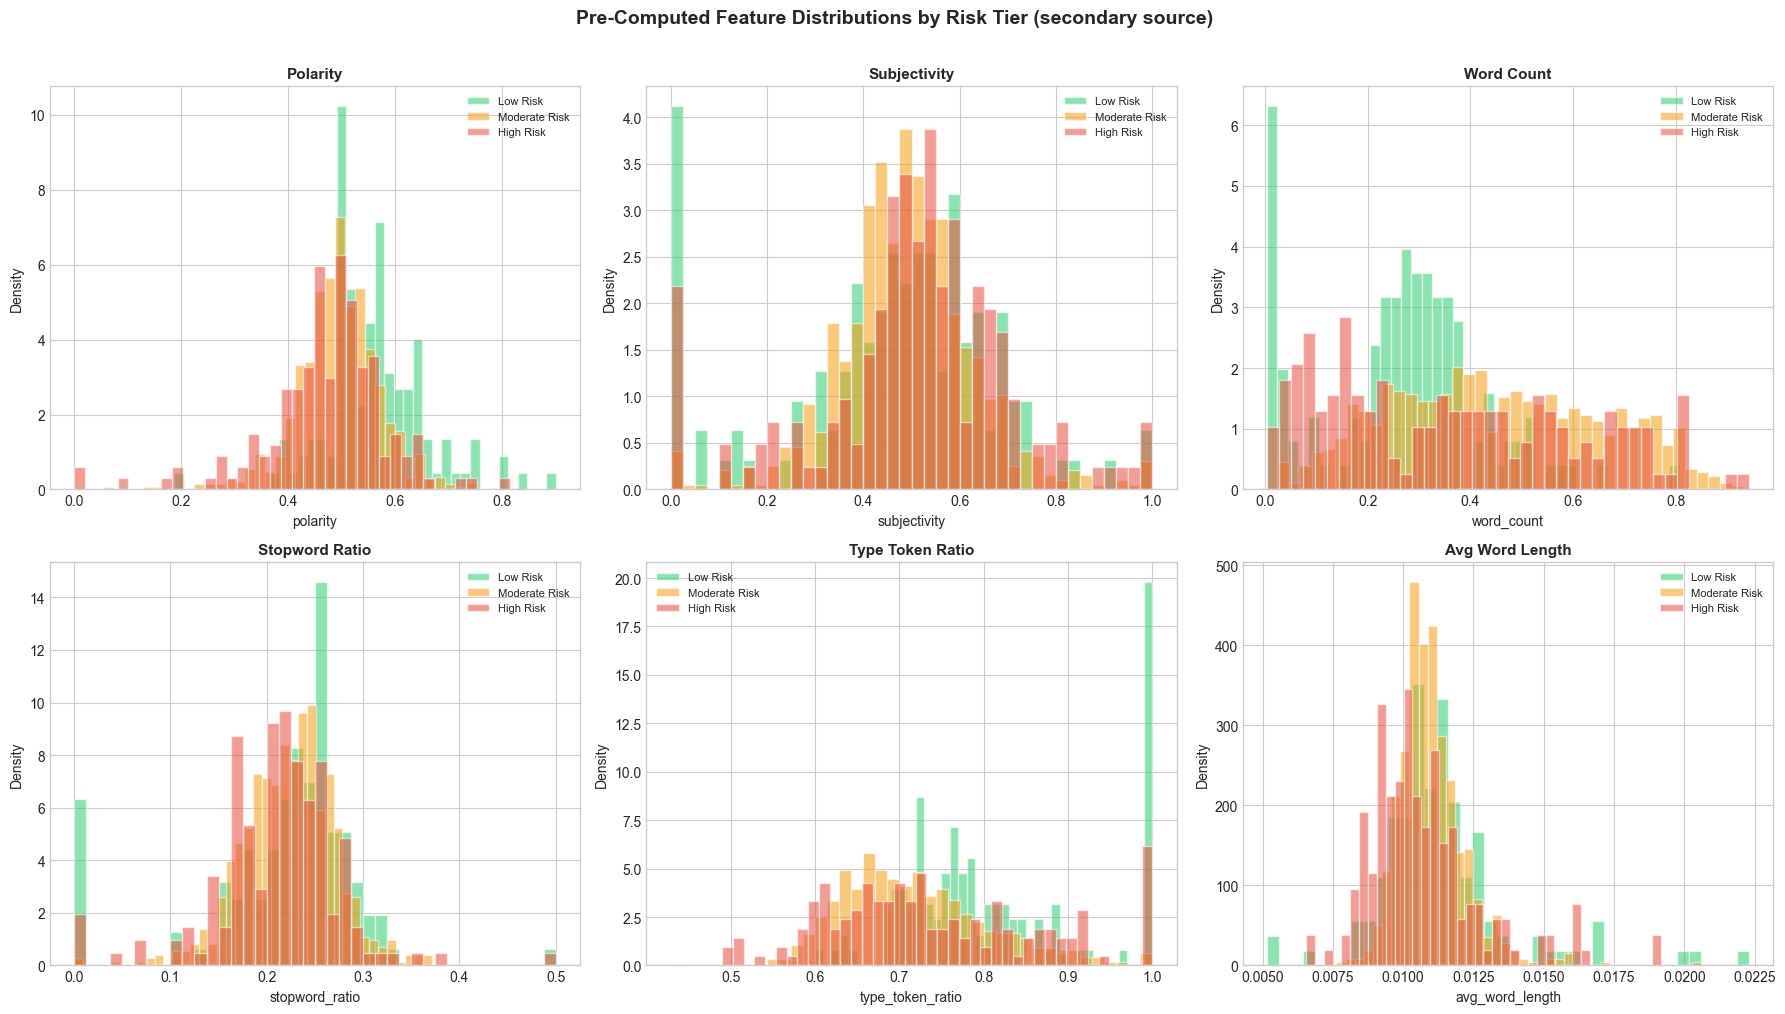

Saved: results/eda_04_feature_distributions.png


In [32]:
numeric_feats = ['polarity', 'subjectivity', 'word_count',
                 'stopword_ratio', 'type_token_ratio', 'avg_word_length']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, feat in zip(axes, numeric_feats):
    for tier, color in zip([0, 1, 2], RISK_PALETTE):
        subset = df_feat_valid[df_feat_valid['risk_label'] == tier][feat].dropna()
        if feat == 'word_count':
            subset = subset.clip(upper=500)
        ax.hist(subset, bins=40, alpha=0.55, color=color,
                label=RISK_NAMES[tier], density=True, edgecolor='white')
    ax.set_title(feat.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Pre-Computed Feature Distributions by Risk Tier (secondary source)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(RESULTS / 'eda_04_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/eda_04_feature_distributions.png')

### 📊 Feature Analysis: Observations

> **Note:** Analysis is based on 1,075 valid rows (secondary source only) — findings are indicative, not statistically conclusive.

---

#### No Useful Separation
All three risk tiers overlap almost completely for these features:

| Feature | Observation |
|---|---|
| **Subjectivity** | All three curves are nearly identical — expected, since all mental health posts are highly subjective regardless of severity |
| **Word Count** | Low Risk spikes at very short texts (K-pop one-liners), but Moderate and High Risk are indistinguishable from each other |
| **Avg Word Length** | Essentially identical distributions across all tiers, clustered around the same range — this feature carries no discriminative signal for this task |

---

#### Weak but Visible Separation

| Feature | Observation |
|---|---|
| **Polarity** | Low Risk peaks more sharply around 0.45–0.55 (more neutral/positive tone). High Risk skews slightly lower (more negative sentiment). Separation is real but modest |
| **Stopword Ratio** | Low Risk spikes near 0 (very short posts with few stopwords — again the K-pop content). High Risk and Moderate Risk remain very similar to each other |

---

#### Most Informative Feature: Type-Token Ratio

Low Risk shows a **massive spike at TTR = 1.0** — short posts where every word is unique.
High Risk and Moderate Risk cluster lower at **0.65–0.80**, indicating more repetitive language patterns.

This is the most theoretically meaningful finding: **rumination and psychological distress correlate with repetitive vocabulary**, which TTR captures directly.

---

#### Takeaway

None of these features are strong enough to use in isolation. `polarity` and `type_token_ratio` together carry marginal combined signal, but critically:

> **The features fail to separate Moderate Risk from High Risk** — the hardest and most clinically important boundary in this dataset. This is precisely where DistilBERT's contextual understanding of language is expected to add the most value.

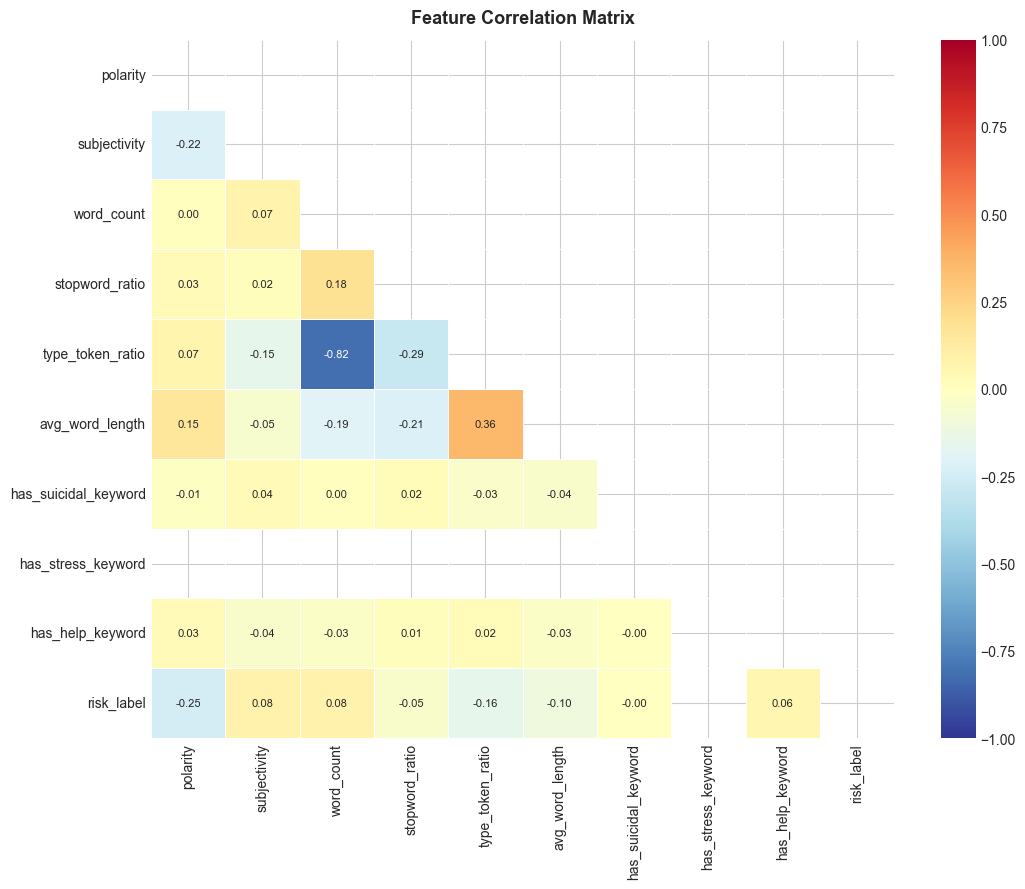

Saved: results/eda_05_feature_correlation.png


In [33]:
# Correlation heatmap
keyword_cols = ['has_suicidal_keyword', 'has_stress_keyword', 'has_help_keyword']
for c in keyword_cols:
    df_feat_valid[c] = df_feat_valid[c].map({True: 1, False: 0, 'True': 1, 'False': 0}).fillna(0)

corr_cols = numeric_feats + keyword_cols + ['risk_label']
corr = df_feat_valid[corr_cols].astype(float).corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(RESULTS / 'eda_05_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/eda_05_feature_correlation.png')

### Feature Correlation Matrix: Observations

> **Note:** Lower triangle only (matrix is symmetric). Values shown only where |r| > 0.05 for readability.

---

#### Critical Multicollinearity: TTR & Word Count

**`type_token_ratio` ↔ `word_count` = −0.82** — this is the strongest relationship in the entire matrix, and it's a well-known **mathematical artifact**, not a real linguistic signal.

As texts get longer, words inevitably repeat → TTR mechanically decreases. This means `type_token_ratio` and `word_count` are **not independent features**. Using both in any linear model would introduce severe multicollinearity. If forced to choose one, prefer `word_count` (more directly interpretable).

---

#### Correlations with `risk_label` (the target)

| Feature | Correlation | Interpretation |
|---|---|---|
| **polarity** | **−0.25** | Strongest signal — more negative sentiment → higher risk |
| **type_token_ratio** | −0.16 | Higher lexical diversity (shorter posts) → lower risk |
| **avg_word_length** | −0.10 | Weak — marginal signal |
| **word_count** | +0.08 | Weak — longer posts slightly higher risk |
| **has_suicidal_keyword** | −0.00 | Effectively zero |
| **has_stress_keyword** | — | Effectively zero |
| **has_help_keyword** | +0.06 | Effectively zero |

All correlations with the target are weak (max |r| = 0.25), confirming the earlier finding that **no single feature is sufficient for classification**.

---

#### The Keyword Features Are Useless

`has_suicidal_keyword`, `has_stress_keyword`, and `has_help_keyword` show **near-zero correlation with everything**, including `risk_label`. This is expected given the multilingual nature of the dataset — English keyword matching completely misses Indonesian, Malay, and Bengali expressions of the same concepts (e.g. *gelisah*, *putus asa*).

---

#### Takeaway

Two things confirmed by this matrix:

1. **`polarity` is the only feature worth keeping** if building a feature-based model — it has the strongest (though still weak) correlation with risk and is not collinear with other useful features
2. **The keyword flags add nothing** — they would actually hurt a model by adding noise dimensions with zero signal

> This further motivates the shift to DistilBERT: contextual embeddings implicitly capture sentiment, repetition, and semantic content **without any of these multicollinearity or keyword-matching limitations**.

---
## 6. Text Cleaning Pipeline

In [50]:
STOP_WORDS = set(stopwords.words('english'))
# Keep negations — critical for mental health context
NEGATIONS  = {'no', 'not', "n't", 'never', 'nobody', 'nothing',
               'neither', 'nor', 'nowhere', 'hardly', 'barely', 'scarcely'}
STOP_WORDS -= NEGATIONS

# Mojibake patterns found in primary dataset
MOJIBAKE_PATTERN = re.compile(
    r'[\u2022\u2018\u2019\u201c\u201d\u2013\u2014\u2026\u00b1\u00b2\u00ab\u00bb'
    r'\u0152\u0153\u017e\u0192\u02c6\u2039\u203a\u20ac\u2122\u00a9\u00ae'
    r'\ufffd\u00e2\u0160\u017d\u00c2\u00c3]+'
)

def clean_text(text: str, for_tfidf: bool = False) -> str:
    """
    Clean a text string.

    for_tfidf=False  →  light clean (DistilBERT): preserve casing + punctuation
    for_tfidf=True   →  aggressive clean (TF-IDF): lowercase, strip stopwords
    """
    if not isinstance(text, str):
        return ''

    # ── Shared: both models ───────────────────────────────────────────────────
    text = text.strip()
    text = re.sub(r'http\S+|www\.\S+', '', text)       # URLs
    text = re.sub(r'@\w+', '', text)                   # @mentions
    text = re.sub(r'#\w+', '', text)                   # hashtags
    text = MOJIBAKE_PATTERN.sub(' ', text)             # mojibake artifacts
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)         # remaining non-ASCII
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'([a-z])([A-Z])', r'\1 \2', text)  # camelCase splitter

    if not for_tfidf:
        return text  # DistilBERT: stop here

    # ── TF-IDF only: aggressive normalisation ─────────────────────────────────
    text = text.lower()
    text = re.sub(r"[^a-z\s]", '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 1]
    return ' '.join(tokens)


print('Applying text cleaning to training set...')
df_clean['text_bert']  = df_clean['text'].apply(lambda t: clean_text(t, for_tfidf=False))
df_clean['text_tfidf'] = df_clean['text'].apply(lambda t: clean_text(t, for_tfidf=True))

print('Applying text cleaning to test set...')
df_test_clean['text_bert']  = df_test_clean['text'].apply(lambda t: clean_text(t, for_tfidf=False))
df_test_clean['text_tfidf'] = df_test_clean['text'].apply(lambda t: clean_text(t, for_tfidf=True))

# ── Show before/after for a primary-source row (mojibake example) ─────────────
ex_primary = df_clean[df_clean['source'] == 'primary'].sample(3, random_state=7)
for _, row in ex_primary.iterrows():
    print(f'\n[{row["status"]} -> {row["risk_name"]}]')
    print(f'  Raw    : {row["text"][:160]}')
    print(f'  BERT   : {row["text_bert"][:160]}')
    print(f'  TF-IDF : {row["text_tfidf"][:160]}')

Applying text cleaning to training set...
Applying text cleaning to test set...

[Normal -> Low Risk]
  Raw    : @BBQNYC thats right unc!!! what a game...
  BERT   : thats right unc!!! what a game...
  TF-IDF : thats right unc game

[Depression -> High Risk]
  Raw    : beautiful but someone in your gender say she s going into depression because her mom wore her nike shoe without informing her
  BERT   : beautiful but someone in your gender say she s going into depression because her mom wore her nike shoe without informing her
  TF-IDF : beautiful someone gender say going depression mom wore nike shoe without informing

[Suicidal -> High Risk]
  Raw    : Sorry for the vent, not doing so hot at this momentIf I do not find a job that can support me with less than a 40 hr work week I really will pass awayWork has o
  BERT   : Sorry for the vent, not doing so hot at this moment If I do not find a job that can support me with less than a 40 hr work week I really will pass away Work has
  TF

---
## 7. Token Length Analysis (DistilBERT)

In [52]:
print('Loading DistilBERT tokenizer...')
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Sample from each source to compare
n_sample = 2500
sample_pri = df_clean[df_clean['source'] == 'primary'].sample(min(n_sample, (df_clean['source']=='primary').sum()), random_state=42)
sample_sec = df_clean[df_clean['source'] == 'secondary'].sample(min(n_sample, (df_clean['source']=='secondary').sum()), random_state=42)
sample_all = pd.concat([sample_pri, sample_sec]).reset_index(drop=True)

print(f'Tokenizing {len(sample_all)} rows (~30s)...')
sample_all['token_len'] = sample_all['text_bert'].apply(
    lambda t: len(tokenizer.encode(str(t), add_special_tokens=True, truncation=False))
)

print('\nToken length by source:')
print(sample_all.groupby('source')['token_len'].describe().round(1))

print('\nCoverage at each cutoff (combined):')
for cutoff in [128, 256, 512]:
    pct = (sample_all['token_len'] <= cutoff).mean() * 100
    print(f'  max_length={cutoff}: {pct:.1f}% --- % of texts fit within {cutoff} tokens' )

Loading DistilBERT tokenizer...


Token indices sequence length is longer than the specified maximum sequence length for this model (709 > 512). Running this sequence through the model will result in indexing errors


Tokenizing 5000 rows (~30s)...

Token length by source:
            count   mean    std  min   25%    50%    75%     max
source                                                          
primary    2500.0  133.3  185.1  2.0  21.0   74.0  172.0  1902.0
secondary  2500.0  170.7  206.5  4.0  56.0  111.0  205.0  2495.0

Coverage at each cutoff (combined):
  max_length=128: 61.8% --- % of texts fit within 128 tokens
  max_length=256: 84.1% --- % of texts fit within 256 tokens
  max_length=512: 95.4% --- % of texts fit within 512 tokens


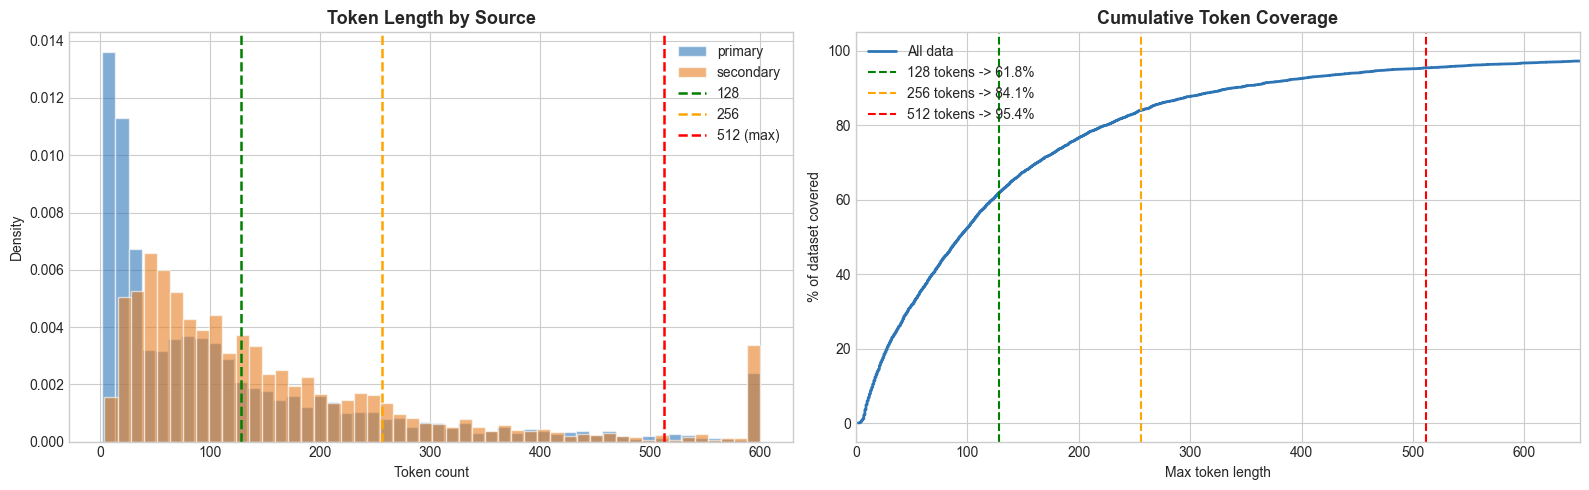

Recommended max_length = 256  (covers 84.1% of texts)


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Histogram by source ───────────────────────────────────────────────────────
for source, color in [('primary', BLUE), ('secondary', '#e67e22')]:
    subset = sample_all[sample_all['source'] == source]['token_len'].clip(upper=600)
    axes[0].hist(subset, bins=50, alpha=0.6, color=color, label=source, density=True, edgecolor='white')
for cutoff, color, label in [(128, 'green', '128'), (256, 'orange', '256'), (512, 'red', '512 (max)')]:
    axes[0].axvline(cutoff, color=color, linestyle='--', linewidth=1.8, label=label)
axes[0].set_title('Token Length by Source', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Token count')
axes[0].set_ylabel('Density')
axes[0].legend()

# ── Cumulative coverage ────────────────────────────────────────────────────────
sorted_t = np.sort(sample_all['token_len'].values)
cdf = np.arange(1, len(sorted_t) + 1) / len(sorted_t)
axes[1].plot(sorted_t, cdf * 100, color=BLUE, linewidth=2, label='All data')
for cutoff, color in [(128, 'green'), (256, 'orange'), (512, 'red')]:
    pct = (sample_all['token_len'] <= cutoff).mean() * 100
    axes[1].axvline(cutoff, color=color, linestyle='--', linewidth=1.5,
                    label=f'{cutoff} tokens -> {pct:.1f}%')
axes[1].set_title('Cumulative Token Coverage', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Max token length')
axes[1].set_ylabel('% of dataset covered')
axes[1].legend()
axes[1].set_xlim(0, 650)

plt.tight_layout()
plt.savefig(RESULTS / 'eda_06_token_length.png', dpi=150, bbox_inches='tight')
plt.show()

RECOMMENDED_MAX_LENGTH = 256
cov = (sample_all['token_len'] <= RECOMMENDED_MAX_LENGTH).mean() * 100
print(f'Recommended max_length = {RECOMMENDED_MAX_LENGTH}  (covers {cov:.1f}% of texts)')

---
## 8. Top Words by Risk Tier

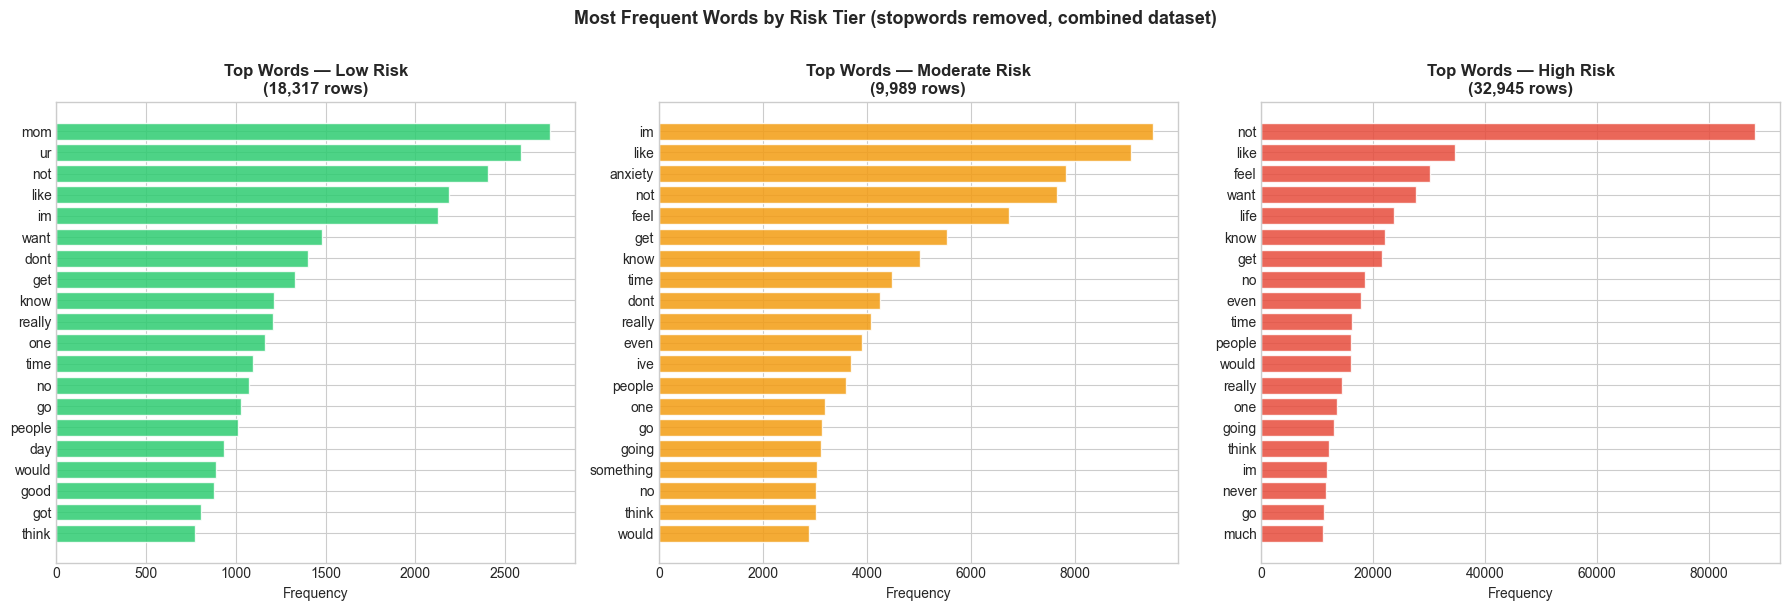

Saved: results/eda_07_top_words.png


In [37]:
def top_n_words(df_subset, col, n=20):
    words = ' '.join(df_subset[col].dropna()).split()
    return pd.DataFrame(Counter(words).most_common(n), columns=['word', 'count'])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, tier, color in zip(axes, [0, 1, 2], RISK_PALETTE):
    subset = df_clean[df_clean['risk_label'] == tier]
    top    = top_n_words(subset, 'text_tfidf', n=20)
    ax.barh(top['word'][::-1], top['count'][::-1], color=color, alpha=0.85, edgecolor='white')
    n_rows = len(subset)
    ax.set_title(f'Top Words — {RISK_NAMES[tier]}\n({n_rows:,} rows)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.suptitle('Most Frequent Words by Risk Tier (stopwords removed, combined dataset)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(RESULTS / 'eda_07_top_words.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/eda_07_top_words.png')

---
## 9. Class Imbalance & Class Weights

In [38]:
counts = df_clean['risk_label'].value_counts().sort_index()
total  = len(df_clean)

print('CLASS IMBALANCE — Combined Training Set')
print('-' * 55)
for label, count in counts.items():
    pct   = count / total * 100
    ratio = counts.max() / count
    print(f'  Class {label} ({RISK_NAMES[label]:<18}): {count:>7,}  ({pct:>5.1f}%)  ratio: {ratio:.1f}x')

print(f'\n  Max imbalance ratio: {counts.max()/counts.min():.1f}x')

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=df_clean['risk_label'].values
)
print('\nClass weights (for DistilBERT Trainer):')
for i, w in enumerate(class_weights):
    print(f'  Class {i} ({RISK_NAMES[i]}): {w:.4f}')

np.save(PROCESSED / 'class_weights.npy', class_weights)
print('\nSaved: data/processed/class_weights.npy')

CLASS IMBALANCE — Combined Training Set
-------------------------------------------------------
  Class 0 (Low Risk          ):  18,317  ( 29.9%)  ratio: 1.8x
  Class 1 (Moderate Risk     ):   9,989  ( 16.3%)  ratio: 3.3x
  Class 2 (High Risk         ):  32,945  ( 53.8%)  ratio: 1.0x

  Max imbalance ratio: 3.3x

Class weights (for DistilBERT Trainer):
  Class 0 (Low Risk): 1.1146
  Class 1 (Moderate Risk): 2.0439
  Class 2 (High Risk): 0.6197

Saved: data/processed/class_weights.npy


---
## 10. Train / Validation Split

In [39]:
# Test set already defined. Split combined training -> 85% train / 15% val.
cols = ['text_bert', 'text_tfidf', 'text', 'status', 'source']
X = df_clean[cols]
y = df_clean['risk_label']

X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)

df_tr  = X_tr.copy();  df_tr['label']  = y_tr.values
df_val = X_val.copy(); df_val['label'] = y_val.values
df_te  = df_test_clean[['text_bert', 'text_tfidf', 'text', 'status']].copy()
df_te['label']  = df_test_clean['risk_label'].values
df_te['source'] = 'test'

print(f'Train : {len(df_tr):>7,}  ({len(df_tr)/total*100:.1f}%)')
print(f'Val   : {len(df_val):>7,}  ({len(df_val)/total*100:.1f}%)')
print(f'Test  : {len(df_te):>7,}  (pre-built balanced, held out)')

print('\nClass distribution per split:')
for sname, df_s in [('Train', df_tr), ('Val', df_val), ('Test', df_te)]:
    d = df_s['label'].value_counts(normalize=True).sort_index().round(3)
    print(f'  {sname}: {dict(d)}')

Train :  52,063  (85.0%)
Val   :   9,188  (15.0%)
Test  :     992  (pre-built balanced, held out)

Class distribution per split:
  Train: {0: np.float64(0.299), 1: np.float64(0.163), 2: np.float64(0.538)}
  Val: {0: np.float64(0.299), 1: np.float64(0.163), 2: np.float64(0.538)}
  Test: {0: np.float64(0.25), 1: np.float64(0.25), 2: np.float64(0.5)}


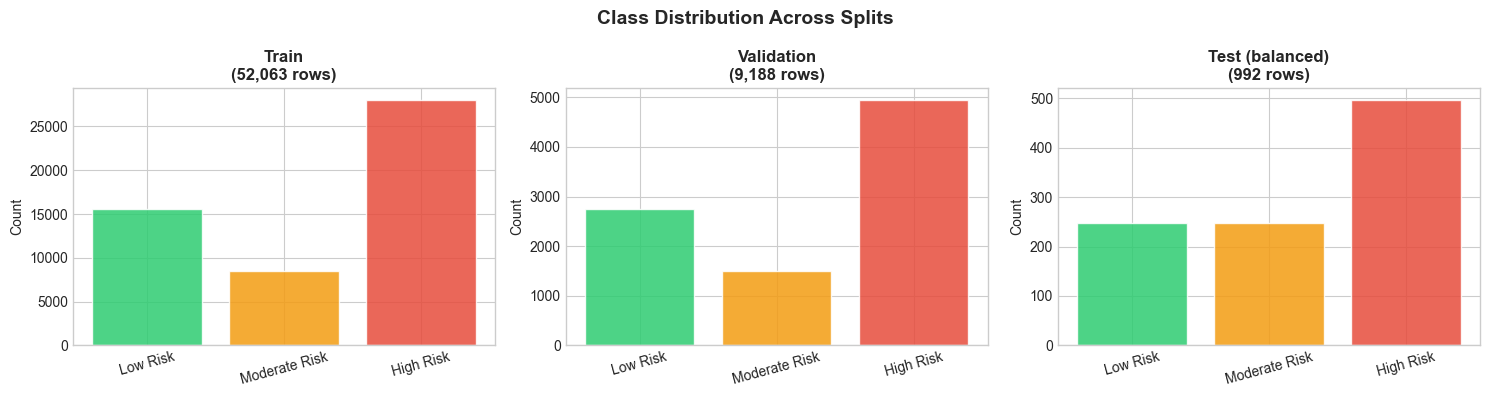

Saved: results/eda_08_split_distribution.png


In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (sname, df_s) in zip(axes, [('Train', df_tr), ('Validation', df_val), ('Test (balanced)', df_te)]):
    c = df_s['label'].value_counts().sort_index()
    ax.bar([RISK_NAMES[i] for i in c.index], c.values,
           color=RISK_PALETTE, alpha=0.85, edgecolor='white')
    ax.set_title(f'{sname}\n({len(df_s):,} rows)', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    ax.set_ylabel('Count')

plt.suptitle('Class Distribution Across Splits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'eda_08_split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/eda_08_split_distribution.png')

---
## 11. Save All Processed Data

In [41]:
df_tr.to_csv( PROCESSED / 'train.csv', index=False)
df_val.to_csv(PROCESSED / 'val.csv',   index=False)
df_te.to_csv( PROCESSED / 'test.csv',  index=False)
df_feat_valid.to_csv(PROCESSED / 'train_features.csv', index=False)

with open(PROCESSED / 'label_map.json', 'w') as f:
    json.dump({
        'label_map'              : LABEL_MAP,
        'risk_names'             : {str(k): v for k, v in RISK_NAMES.items()},
        'recommended_max_length' : RECOMMENDED_MAX_LENGTH,
        'class_weights'          : class_weights.tolist(),
    }, f, indent=2)

print('Saved processed data:')
for fp in sorted(PROCESSED.iterdir()):
    print(f'  {fp.name:<35} {fp.stat().st_size / 1024:>8.1f} KB')

Saved processed data:
  class_weights.npy                        0.1 KB
  label_map.json                           0.4 KB
  test.csv                              1964.7 KB
  train.csv                            80748.4 KB
  train_features.csv                     864.8 KB
  val.csv                              14409.6 KB


---
## 12. EDA Summary

In [53]:
print('=' * 62)
print('EDA SUMMARY')
print('=' * 62)
print(f'  Primary source rows     : 53,043  (7 labels, mixed EN/ID)')
print(f'  Secondary source rows   : 49,612  (4 labels, English)')
print(f'  After merge & cleaning  : {total:,}')
print(f'  Train / Val / Test      : {len(df_tr):,} / {len(df_val):,} / {len(df_te):,}')
print()
print('  Label mapping (7 -> 3 risk tiers):')
for orig, tier in LABEL_MAP.items():
    print(f'    {orig:<22} -> Class {tier}  ({RISK_NAMES[tier]})')
print()
print('  Class weights (for DistilBERT):')
for i, w in enumerate(class_weights):
    n = (df_clean['risk_label'] == i).sum()
    print(f'    Class {i} ({RISK_NAMES[i]}): weight={w:.4f}  n={n:,}')
print()
print(f'  Recommended max_length  : {RECOMMENDED_MAX_LENGTH} tokens')
print(f'  Output files            : data/processed/ (train, val, test, features, label_map)')
print(f'  Output charts           : results/eda_01 through eda_08')
print()
print('  Next:')
print('    02_baseline_model.ipynb       <- reads text_tfidf + label')
print('    03_distilbert_finetune.ipynb  <- reads text_bert + label')

EDA SUMMARY
  Primary source rows     : 53,043  (7 labels, mixed EN/ID)
  Secondary source rows   : 49,612  (4 labels, English)
  After merge & cleaning  : 61,251
  Train / Val / Test      : 52,063 / 9,188 / 992

  Label mapping (7 -> 3 risk tiers):
    Normal                 -> Class 0  (Low Risk)
    Stress                 -> Class 1  (Moderate Risk)
    Anxiety                -> Class 1  (Moderate Risk)
    Personality disorder   -> Class 1  (Moderate Risk)
    Depression             -> Class 2  (High Risk)
    Suicidal               -> Class 2  (High Risk)
    Bipolar                -> Class 2  (High Risk)

  Class weights (for DistilBERT):
    Class 0 (Low Risk): weight=1.1146  n=18,317
    Class 1 (Moderate Risk): weight=2.0439  n=9,989
    Class 2 (High Risk): weight=0.6197  n=32,945

  Recommended max_length  : 256 tokens
  Output files            : data/processed/ (train, val, test, features, label_map)
  Output charts           : results/eda_01 through eda_08

  Next:
    02_